In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from PIL import Image
import seaborn as sns

(512, 512)

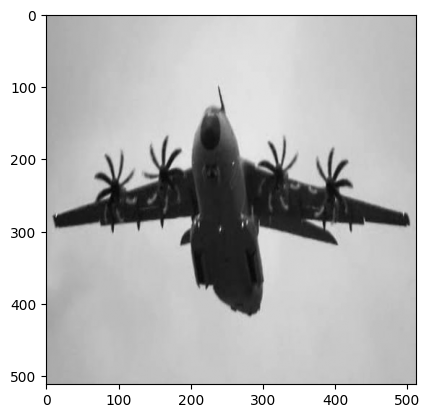

In [ ]:
image_list=["/content/new-aircraft.jpg","/content/baboon.tiff","/content/lena.tiff"]
image="/content/jet.jpg"
im=cv2.imread(image,0)
plt.imshow(im,cmap='gray')
im.shape

In [ ]:
from PIL import Image

def divide_into_blocks(image_path, block_size=(8, 8)):
    # Open the image
    image = Image.open(image_path)

    # Get the image dimensions
    width, height = image.size
    block_width, block_height = block_size

    # Pad image to fit blocks if needed
    pad_w = (block_size[0] - width % block_size[0]) % block_size[0]
    pad_h = (block_size[1] - height % block_size[1]) % block_size[1]
    image_padded = np.pad(im, ((0, pad_h), (0, pad_w)), mode='constant')

    width_p, height_p = image_padded.shape

    # List to hold the blocks
    blocks = []

    # Loop through the image and create blocks
    for y in range(0, height_p, block_height):
        for x in range(0, width_p, block_width):
            # Define the coordinates for the current block
            box = (x, y, min(x + block_width, width_p), min(y + block_height, height_p))

            # Crop the image to get the block and add to the list
            block = image.crop(box)
            blocks.append(block)

    return blocks

# Example usage
blocks = divide_into_blocks(image)

# Total number of blocks
print(f"Total blocks: {len(blocks)}")


Total blocks: 4096


In [ ]:
Entropy=[]
for block in blocks:
    Entropy.append(block.entropy())
print(len(blocks),len(Entropy))

4096 4096


In [ ]:
#block_no=[]
#for i in range(1,len(blocks)+1):
#    block_no.append(i)

In [ ]:
Energy=[]
for block in blocks:
    # Energy as sum of squared pixel values (you can also use np.var or np.sum(np.abs(np.gradient)))
    block=np.array(block)
    Energy.append(np.sum(np.square(block.astype(np.float32))))
    #Energy.append(np.var(block))

In [ ]:
#Correlation=[]
#for block in blocks:
#    Correlation.append(np.corrcoef(block,block))
#print(len(blocks),len(Correlation))

In [ ]:
Contrast=[]
for block in blocks:
    block = np.array(block)
    # Contrast = standard deviation of pixel intensities
    Contrast.append(block.std())

In [ ]:
#from skimage import io, color
#from skimage.feature import graycomatrix
#from skimage.feature import greycoprops
#Homogeneity=[]
#for block in blocks:
#    gray_image = color.rgb2gray(block)

    # Scale gray levels to 8-bit range (0-255) and convert to uint8
#    gray_image = (gray_image * 255).astype(np.uint8)

    # Compute GLCM
#    glcm = graycomatrix(gray_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    # Calculate homogeneity
#    homogeneity = greycoprops(glcm, prop='homogeneity')

 #   Homogeneity.append(homogeneity[0, 0])

In [ ]:
from skimage.feature import graycomatrix
from skimage.feature import graycoprops

def compute_homogeneity(block):
    # Convert the block to grayscale before computing GLCM
    block = block.convert("L")  # Convert to grayscale using 'L' mode
    block = np.array(block)
    glcm = graycomatrix(block, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    return homogeneity

Homogeneity=[]
for block in blocks:
    # block = np.array(block)  # No need to convert to NumPy array here
    Homogeneity.append(compute_homogeneity(block))
inverse_homogeneity=[]
for i in Homogeneity:
    inverse_homogeneity.append(1/i)

In [ ]:
def sorted_kmeans(**kwargs):
    import pandas as pd
    import numpy as np
    from sklearn.cluster import KMeans
    data = {**kwargs}
    df = pd.DataFrame(data)

    km=KMeans(n_clusters=3)
    km.fit(df)
    ym=km.predict(df)
    label=km.labels_
    label=list(label)

    centers=km.cluster_centers_

    # Sort centers based on the sum of coordinates
    sorted_indices = np.argsort(centers.sum(axis=1))
    sorted_centers = centers[sorted_indices]

    # Create a mapping from old cluster indices to new labels (0, 1, 2)
    new_labels_map = {sorted_indices[i]: i for i in range(3)}

    # Assign new labels to data points
    new_labels = np.array([new_labels_map[label] for label in km.labels_])

    from sklearn.cluster import KMeans
    km=KMeans(n_clusters=3)
    km.fit(df)
    ym=km.predict(df)
    label=km.labels_
    label=list(label)

    centers=km.cluster_centers_

    # Sort centers based on the sum of coordinates
    sorted_indices = np.argsort(centers.sum(axis=1))
    sorted_centers = centers[sorted_indices]

    # Create a mapping from old cluster indices to new labels (0, 1, 2)
    new_labels_map = {sorted_indices[i]: i for i in range(3)}

    # Assign new labels to data points
    new_labels = np.array([new_labels_map[label] for label in km.labels_])

    df['label']=new_labels
    return df

In [ ]:
#num_blocks_y = image_padded.shape[0] // block_size[0]
#num_blocks_x = image_padded.shape[1] // block_size[1]
#classification_map = np.empty((num_blocks_y, num_blocks_x), dtype=object)
#idx = 0
#for i in range(num_blocks_y):
#    for j in range(num_blocks_x):
#        label = labels[idx]
#        classification_map[i, j] = label_mapping[label]
#        idx += 1
#
#return classification_map
#def display_classification(image, classification_map, block_size=(32, 32)):
#    output = image.copy()
#    block_h, block_w = block_size
#    for i, row in enumerate(classification_map):
#        for j, label in enumerate(row):
#            color = (0, 255, 0) if label == 'Low' else (0, 255, 255) if label == 'Medium' else (0, 0, 255)
#            y, x = i * block_h, j * block_w
#            cv2.rectangle(output, (x, y), (x + block_w, y + block_h), color, 1)
#            cv2.putText(output, label[0], (x + 5, y + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

#    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
#    plt.figure(figsize=(8, 8))
#   plt.imshow(output_rgb)
#    plt.title("Block Contrast Classification")
#    plt.axis('off')
#    plt.show()

#image_path = 'aircraft.jpg'
#gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#color = cv2.imread(image_path)

#classification_map = classify_blocks_by_contrast(gray)
#display_classification(color, classification_map)

In [ ]:
print(sorted_kmeans(Entropy=Entropy))

       Entropy  label
0     3.126109      1
1     3.261399      1
2     3.612976      1
3     2.127048      0
4     3.700074      1
...        ...    ...
4091  3.396241      1
4092  3.084963      1
4093  3.716511      1
4094  1.584963      0
4095  3.866579      1

[4096 rows x 2 columns]


In [ ]:
# prompt: apply rgb color in each block according to the labels

import matplotlib.pyplot as plt
import numpy as np
# Define RGB colors for each label
# You can choose any colors you like
label_colors = {
    0: (255, 0, 0),   # Red for label 0
    1: (0, 255, 0),   # Green for label 1
    2: (0, 0, 255)    # Blue for label 2
}

def display_classified_image(image_path, blocks, labels, block_size=(8, 8)):
    # Open the image
    image = Image.open(image_path).convert("RGB") # Convert to RGB for coloring
    width, height = image.size
    block_width, block_height = block_size

    # Pad image if needed (should be the same padding as in divide_into_blocks)
    pad_w = (block_size[0] - width % block_size[0]) % block_size[0]
    pad_h = (block_size[1] - height % block_size[1]) % block_size[1]
    # Use the original grayscale image 'im' for padding calculation
    width_p, height_p = np.pad(im, ((0, pad_h), (0, pad_w)), mode='constant').shape

    # Create a blank image with the same padded dimensions to draw the colored blocks
    classified_image = Image.new('RGB', (width_p, height_p))

    block_index = 0
    for y in range(0, height_p, block_height):
        for x in range(0, width_p, block_width):
            if block_index < len(labels):
                label = labels[block_index]
                color = label_colors.get(label, (255, 255, 255)) # Default to white if label not found

                # Create a block of the assigned color
                color_block = Image.new('RGB', (block_width, block_height), color)

                # Paste the color block onto the classified image
                classified_image.paste(color_block, (x, y))

                block_index += 1

    # Crop the image back to original size (optional, but good if you want to see the original dimensions)
    # classified_image = classified_image.crop((0, 0, width, height))

    plt.figure(figsize=(5, 5))
    plt.imshow(classified_image)
    plt.title("Image Blocks Classified by colors")
    plt.axis('off')
    plt.show()


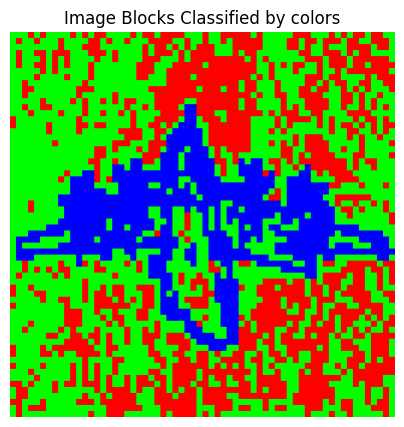

In [ ]:
# Get the labels from the sorted_kmeans result
df_classified = sorted_kmeans(Entropy=Entropy)
labels = df_classified['label'].tolist()

# Display the classified image with colored blocks
display_classified_image(image, blocks, labels)

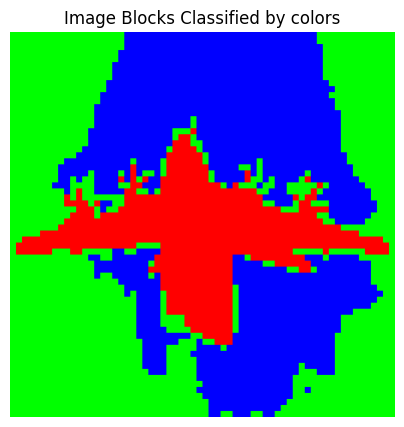

In [ ]:
# Get the labels from the sorted_kmeans result
df_classified = sorted_kmeans(Energy=Energy)
labels = df_classified['label'].tolist()

# Display the classified image with colored blocks
display_classified_image(image, blocks, labels)

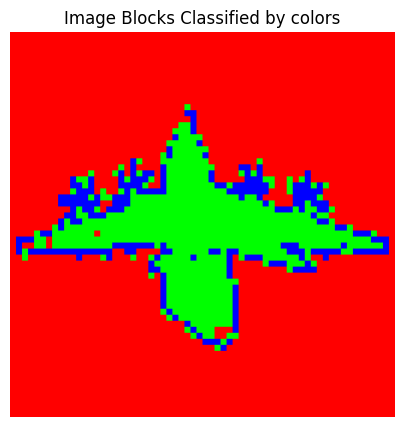

In [ ]:
# Get the labels from the sorted_kmeans result
df_classified = sorted_kmeans(Contrast=Contrast)
labels = df_classified['label'].tolist()

# Display the classified image with colored blocks
display_classified_image(image, blocks, labels)

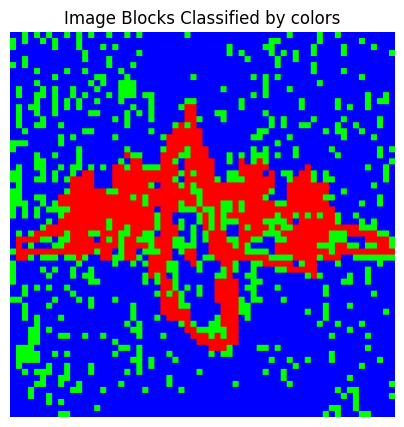

In [ ]:
# Get the labels from the sorted_kmeans result
df_classified = sorted_kmeans(Homogeneity=Homogeneity)
labels = df_classified['label'].tolist()

# Display the classified image with colored blocks
display_classified_image(image, blocks, labels)

       Entropy    Energy  Contrast  Homogeneity  label
0    -0.173557 -0.344740 -0.100781    -0.216538      0
1    -0.086919 -0.314033 -0.169844    -0.245645      0
2     0.138227 -0.264332 -0.182772    -0.198016      0
3    -0.813346 -0.199353 -0.185727    -0.245645      0
4     0.194004 -0.160692 -0.054356    -0.148623      0
...        ...       ...       ...          ...    ...
4091 -0.000568  0.085841 -0.522750    -0.175789      0
4092 -0.199907  0.065157 -0.531057    -0.245645      0
4093  0.204530  0.064339 -0.516873    -0.216538      0
4094 -1.160492  0.113445 -0.551671    -0.245645      0
4095  0.300632  0.064786 -0.511382    -0.212203      0

[4096 rows x 5 columns]


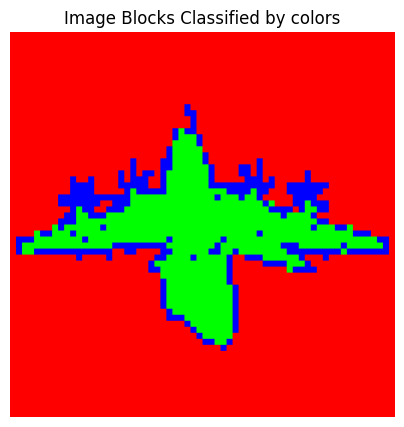

In [ ]:
from sklearn.preprocessing import StandardScaler
st_x= StandardScaler()

# Reshape the 1D lists to 2D arrays with a single column
Entropy= st_x.fit_transform(np.array(Entropy).reshape(-1, 1)).flatten() # Flatten the output
Energy= st_x.fit_transform(np.array(Energy).reshape(-1, 1)).flatten()   # Flatten the output
Contrast= st_x.fit_transform(np.array(Contrast).reshape(-1, 1)).flatten() # Flatten the output
Homogeneity= st_x.fit_transform(np.array(Homogeneity).reshape(-1, 1)).flatten() # Flatten the output
inverse_homogeneity=st_x.fit_transform(np.array(inverse_homogeneity).reshape(-1, 1)).flatten()
df_new=sorted_kmeans(Entropy= Entropy,Energy= Energy,Contrast= Contrast,Homogeneity=inverse_homogeneity)
labels = df_new['label'].tolist()
print(df_new)

# Display the classified image with colored blocks
display_classified_image(image, blocks, labels)

In [ ]:
high_mid_info_index = df_new[df_new['label'].isin([1, 2])].index.tolist() # Use 'labels' column nameolist() # Use 'labels' column name

In [ ]:
#if 'label' in df_new.columns:
df_new = df_new.drop('label', axis=1)

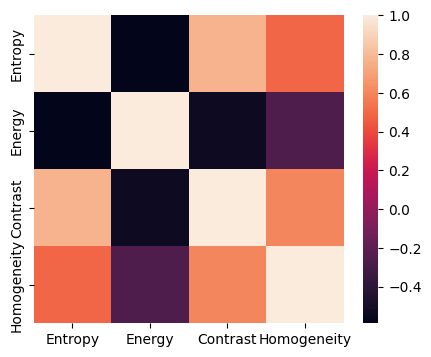

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(df_new.corr())
plt.show()

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_new)
labels = pd.DataFrame(kmeans.labels_, columns=['labels'])
df_new = pd.concat([df_new,labels],axis=1)
df_new

,Entropy,Energy,Contrast,Homogeneity,labels
0,-0.173557,-0.344740,-0.100781,-0.216538,0
1,-0.086919,-0.314033,-0.169844,-0.245645,0
2,0.138227,-0.264332,-0.182772,-0.198016,0
3,-0.813346,-0.199353,-0.185727,-0.245645,0
4,0.194004,-0.160692,-0.054356,-0.148623,0
...,...,...,...,...,...
4091,-0.000568,0.085841,-0.522750,-0.175789,0
4092,-0.199907,0.065157,-0.531057,-0.245645,0
4093,0.204530,0.064339,-0.516873,-0.216538,0
4094,-1.160492,0.113445,-0.551671,-0.245645,0


In [ ]:
df_new.to_csv('output.csv', index=False)

In [ ]:

#from sklearn.neighbors import KNeighborsClassifier

# Assuming df_new is already defined and contains the features
# and you want to predict the 'labels' column

# Separate features (X) and target variable (y)
#X = df_new.drop('labels', axis=1)
#y = df_new['labels']

# Initialize KNN classifier (you can adjust the number of neighbors)
#knn = KNeighborsClassifier(n_neighbors=3)

# Fit the classifier to the data
#knn.fit(X, y)

# Now you can use knn.predict(new_data) to predict labels for new data
# where new_data has the same features as X


In [ ]:
# Splitting the dataset into training and test set.
from sklearn.model_selection import train_test_split

# Define x and y here
x = df_new.drop('labels', axis=1)  # Features
y = df_new['labels']  # Target variable

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.25, random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
st_x= StandardScaler()
x_train= st_x.fit_transform(x_train)
x_test= st_x.transform(x_test)

In [ ]:
##Fitting K-NN classifier to the training set
from sklearn.neighbors import KNeighborsClassifier
classifier= KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2 )
classifier.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
x_train[0]

array([-1.16890619,  0.77480422, -0.38776111, -0.24910167])

In [ ]:
#Predicting the test set result
y_pred= classifier.predict(x_test)

In [ ]:
len(x_test)

1024

In [ ]:
y_pred

array([0, 1, 1, ..., 0, 1, 0], dtype=int32)

In [ ]:
#Creating the Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
cm= confusion_matrix(y_test, y_pred)


In [ ]:
from sklearn import metrics
score=metrics.accuracy_score(y_test,y_pred)

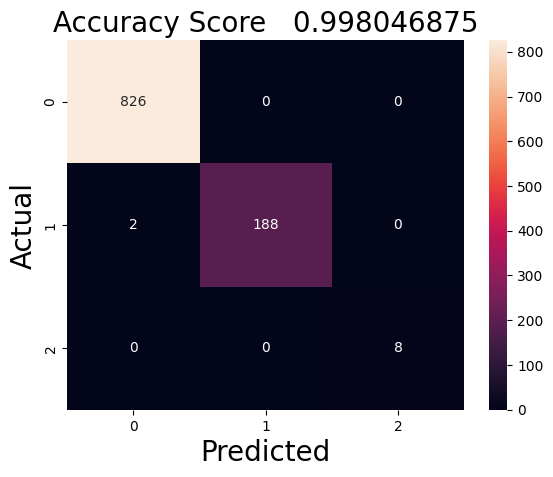

In [ ]:
heatmap = sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.title('Accuracy Score   {0}'.format(score),fontsize=20)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      0.99      0.99       190
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



In [ ]:
#Fitting Decision Tree classifier to the training set
from sklearn.tree import DecisionTreeClassifier
classifier= DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
#Predicting the test set result
y_pred= classifier.predict(x_test)

In [ ]:
#Creating the Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In [ ]:
y_pred

array([0, 1, 1, ..., 0, 1, 0], dtype=int32)

In [ ]:
from sklearn import metrics
score=metrics.accuracy_score(y_test,y_pred)

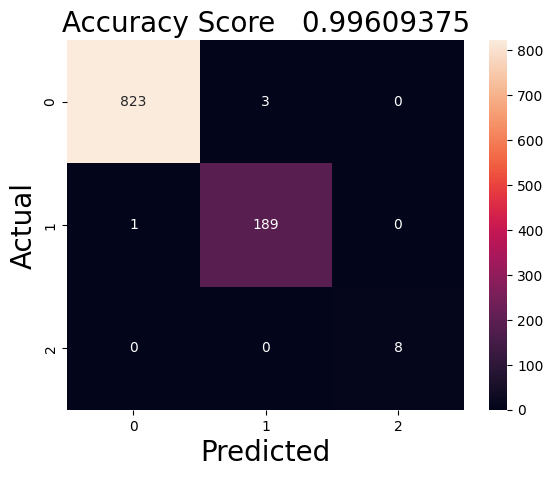

In [ ]:
heatmap = sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.title('Accuracy Score   {0}'.format(score),fontsize=20)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       0.98      0.99      0.99       190
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1024
   macro avg       0.99      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model=RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
#Accuracy scores
score=metrics.accuracy_score(y_test,y_pred)
#Confusion metrices
cf=metrics.confusion_matrix(y_test,y_pred)

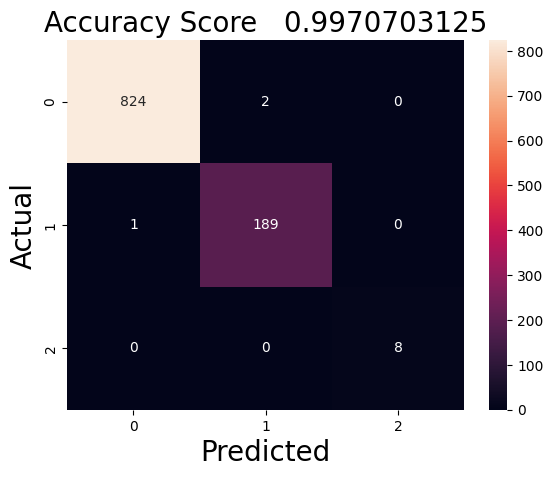

In [ ]:
heatmap = sns.heatmap(cf, annot=True, fmt="d")
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.title('Accuracy Score   {0}'.format(score),fontsize=20)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       0.99      0.99      0.99       190
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



In [ ]:
from sklearn import svm

In [ ]:
model = svm.SVC(kernel='linear')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
#Accuracy scores
score=metrics.accuracy_score(y_test,y_pred)
#Confusion metrices
cf=metrics.confusion_matrix(y_test,y_pred)

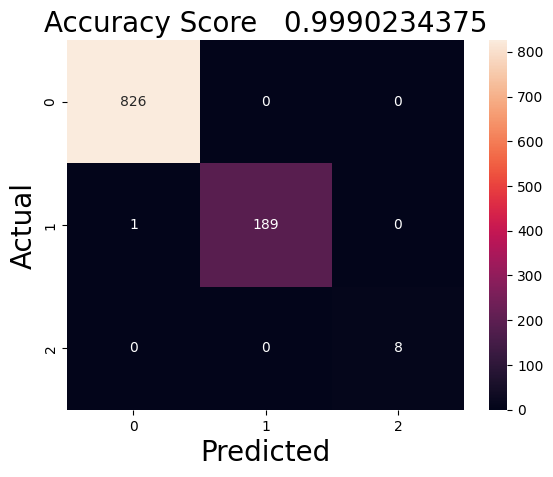

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      0.99      1.00       190
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



In [ ]:
heatmap = sns.heatmap(cf, annot=True, fmt="d")
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.title('Accuracy Score   {0}'.format(score),fontsize=20)
plt.show()
print(classification_report(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model=GaussianNB()
model.fit(x_train,y_train)
y_prediction=model.predict(x_test)
score=metrics.accuracy_score(y_test,y_prediction)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       826
           1       1.00      0.99      1.00       190
           2       1.00      1.00      1.00         8

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



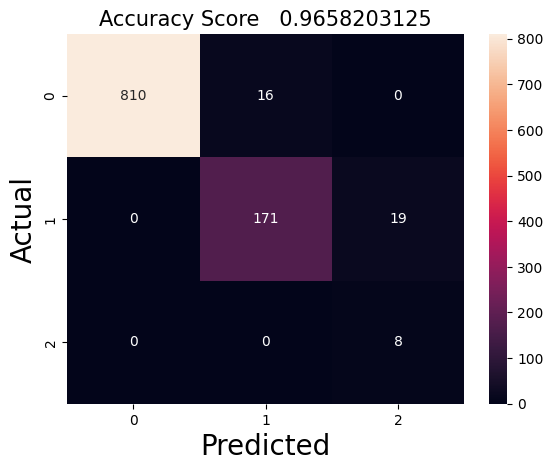

In [ ]:
cf=metrics.confusion_matrix(y_test,y_prediction)
heatmap = sns.heatmap(cf, annot=True, fmt="d")
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.title('Accuracy Score   {0}'.format(score),fontsize=15)
print(classification_report(y_test,y_pred))

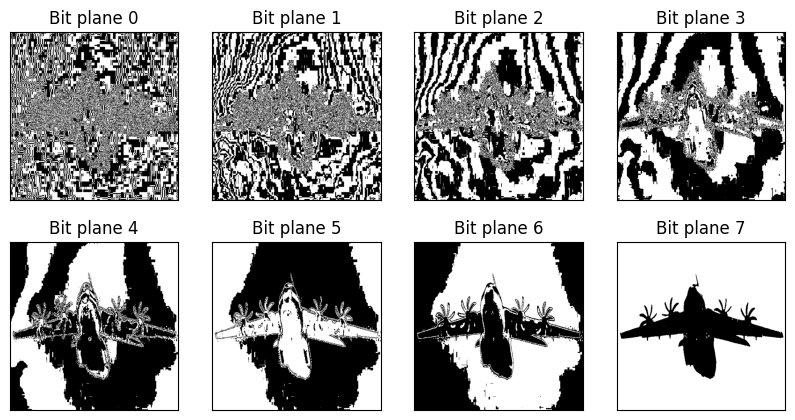

In [ ]:
def bit_plane_slicing(image_path):
  # Load the image in grayscale
  img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

  rows, cols = img.shape
  bit_planes = []

  # Extract each bit plane (0 to 7)
  for i in range(8):
      # Use bitwise AND to isolate the bit plane, then shift to make it visible
      plane = cv2.bitwise_and(img, 1 << i)
      plane = np.where(plane > 0, 255, 0).astype(np.uint8)
      bit_planes.append(plane)

  return bit_planes

# Call the function to get the bit planes
#for block in blocks:
#   bit_planes = bit_plane_slicing(block)
bit_planes = bit_plane_slicing(image) # Moved outside the function definition

plt.figure(figsize=(10,5))
for i in range (8):
    plt.subplot(2,4,i+1)
    plt.title("Bit plane " +str(i))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(bit_planes[i],cmap='gray')
plt.show()

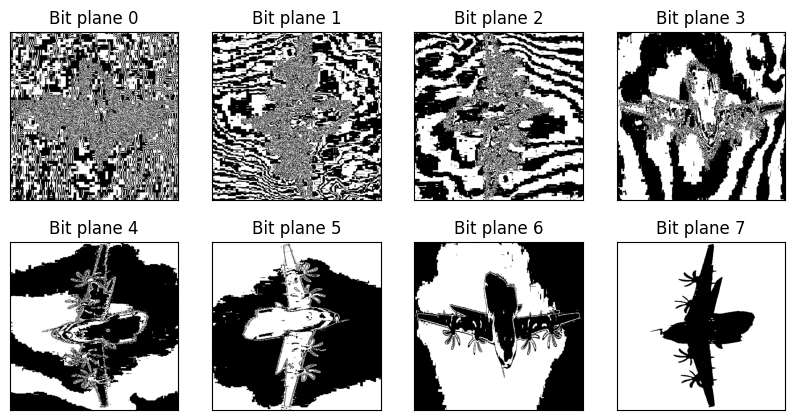

In [ ]:
# prompt: Rotate last bit plane by 180 degree

def rotate_bit_plane(plane, angle):
    """Rotates a bit plane by a given angle."""
    rows, cols = plane.shape
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
    rotated_plane = cv2.warpAffine(plane, M, (cols, rows))
    return rotated_plane

def final_rotated_bitplanes(bit_planes):
  rotated_bit_planes = []  # Reset the list to store rotated planes
  angle = 90

  for i in reversed(range(8)):
      if angle > 270:
          angle = 90
      rotated_bit_planes.append(rotate_bit_plane(bit_planes[i], angle))  # Append rotated plane to list
      angle += 90
  rotated_bit_planes=rotated_bit_planes[::-1]
  return rotated_bit_planes

# Call the function to get the rotated bit planes
rotated_bit_planes = final_rotated_bitplanes(bit_planes)

# Display the rotated bit planes (example for the first bit plane)
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.title("Bit plane " + str(i))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(rotated_bit_planes[i], cmap='gray')  # Access the elements of rotated_bit_planes
plt.show()


[1, 44, 30, 9, 23, 58, 6, 41, 61, 16, 49, 37, 26, 19, 54, 2, 12, 45, 33, 31, 10, 24, 35, 47, 14, 59, 4, 56, 21, 7, 42, 28, 39, 62, 17, 52, 50, 51, 38, 27, 20, 55, 3, 13, 46, 34, 32, 11, 53, 18, 63, 25, 36, 48, 15, 60, 40, 5, 57, 22, 8, 29, 43, 0]
Length of the sequence: 64
Number of unique elements: 64


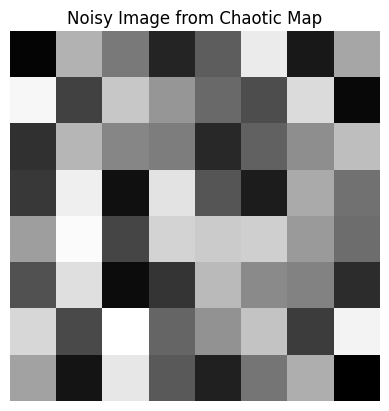

In [ ]:
# prompt: generate random sequence using chaotic map of 64 numbers range between 0 to 63 with no repetations

import random

def generate_chaotic_sequence(size, min_val, max_val):
    """
    Generates a chaotic sequence using a simple logistic map.
    Then shuffles and samples to get a sequence with no repetitions.
    Note: This is a simplistic approach for demonstration.
    True chaotic systems require careful parameter selection and initial conditions.
    """
    if max_val - min_val + 1 < size:
        raise ValueError("Range must be at least as large as the desired sequence size.")

    # Use a simple chaotic map (logistic map) to generate a sequence of values.
    # We'll use these values to influence a shuffle.
    # The specific map and parameters here are just for demonstration.
    r = 3.9  # Parameter for the logistic map
    x = 0.5  # Initial condition (between 0 and 1)
    chaotic_values = []
    for _ in range(size * 2): # Generate more values than needed to help with shuffling
        x = r * x * (1 - x)
        chaotic_values.append(x)

    # Create a list of numbers in the desired range
    numbers = list(range(min_val, max_val + 1))

    # Shuffle the numbers using the chaotic values as "randomness" source.
    # A simple way is to pair numbers with chaotic values and sort.
    paired = list(zip(numbers, chaotic_values[:len(numbers)]))
    paired.sort(key=lambda item: item[1])
    shuffled_numbers = [num for num, _ in paired]

    # Take the first 'size' elements from the shuffled list
    sequence = shuffled_numbers[:size]

    return sequence

# Generate a chaotic sequence of 64 numbers in the range 0 to 63 with no repetitions
sequence = generate_chaotic_sequence(64, 0, 63)
print(sequence)
print(f"Length of the sequence: {len(sequence)}")
print(f"Number of unique elements: {len(set(sequence))}")
def chaotic_to_image(sequence):
    #scaled = np.floor(sequence * 256).astype(np.uint8)
    # The reshape target shape should match the size of the sequence
    image = np.reshape(sequence, (8, 8))
    return image
block_noisy_image=chaotic_to_image(sequence)
plt.imshow(block_noisy_image, cmap='gray')
plt.title("Noisy Image from Chaotic Map")
plt.axis('off')
plt.show()

[187  69  29 221  37 144 236 228  10  42 161  28 221  36 138 221 226  17
  69   3 253 201  45  91 184 175  64 204 102 109 157  17  23 143 131 101
 148  47  75  13 225  20  79  34  54  66 203 107 127 174 213 156 113 156
 198 127 186 215  60 226 186  70  25 222]
[187  69  29 ...  71 109 168]


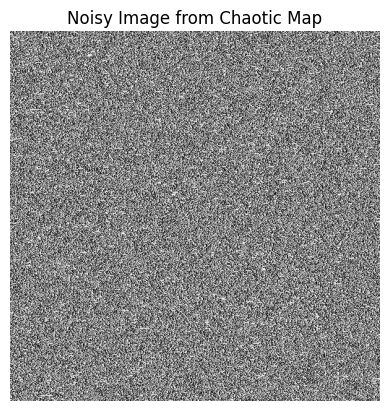

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_chaotic_sequence(seed, r, N):
    """
    Generate a chaotic sequence using the logistic map.

    Parameters:
    - seed: Initial value between 0 and 1 (not 0 or 1)
    - r: Logistic map parameter (chaotic behavior in [3.57, 4])
    - N: Number of values to generate

    Returns:
    - chaotic_seq: numpy array of values in (0, 1)
    """
    chaotic_seq = np.zeros(N)
    chaotic_seq[0] = seed
    for i in range(1, N):
        chaotic_seq[i] = r * chaotic_seq[i - 1] * (1 - chaotic_seq[i - 1])
    # Return all elements from the beginning to have N elements
    Mod = np.floor(chaotic_seq[0:] * 999).astype(int) % 256
    return Mod

def chaotic_to_image(sequence):
    #scaled = np.floor(sequence * 256).astype(np.uint8)
    # The reshape target shape should match the size of the sequence
    image = np.reshape(sequence, (512, 512))
    return image

# Generate chaotic sequence and noisy image
block_chaotic_seq = generate_chaotic_sequence(seed=0.7, r=3.99, N=8*8)
print(block_chaotic_seq)
# Generate a sequence of 512*512 elements for the 512x512 image
full_chaotic_seq = generate_chaotic_sequence(seed=0.7, r=3.99, N=512*512)
print(full_chaotic_seq)
noisy_image = chaotic_to_image(full_chaotic_seq)

# Display the noisy image
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Image from Chaotic Map")
plt.axis('off')
plt.show()

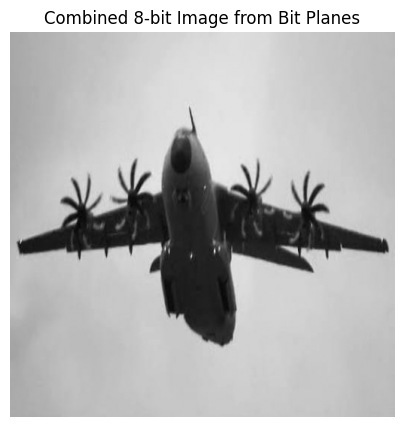

In [ ]:
# prompt: program to combine 8 bit planes

import matplotlib.pyplot as plt
import numpy as np
def combine_bit_planes(bit_planes):
    """
    Combines a list of 8-bit planes into a single 8-bit grayscale image.

    Parameters:
    - bit_planes: A list of 8 NumPy arrays, where each array represents a bit plane
                  (should have the same dimensions and be of type uint8).

    Returns:
    - combined_image: A NumPy array representing the combined 8-bit grayscale image.
    """
    if len(bit_planes) != 8:
        raise ValueError("Need exactly 8 bit planes to combine.")

    # Initialize the combined image as a zero array with the same dimensions as a plane
    rows, cols = bit_planes[0].shape
    combined_image = np.zeros((rows, cols), dtype=np.uint8)

    # Combine the bit planes
    for i in range(8):
        # The i-th bit plane contributes to the i-th bit position
        # We need to shift the values in each plane to their correct bit position
        # Since the planes are already scaled to 0 or 255, we can simply add them.
        # For example, if bit plane 0 has value 255 where the bit is 1, adding it
        # directly to combined_image will set the last bit. For bit plane 1, we
        # would ideally shift values by 1 (or just add as is if the plane represents
        # the actual bit value multiplied by 2^i).
        # Assuming the bit planes are binary (0 or 255) and 255 represents a bit value of 1
        # for that plane's position, we need to scale them correctly.
        # A more robust way: get the actual bit value (0 or 1) and multiply by 2^i
        bit_plane_value = (bit_planes[i] > 0).astype(np.uint8) # Get 0 or 1
        combined_image += bit_plane_value * (2 ** i)


    return combined_image

# Example of how to use the function with the previously extracted bit_planes
# The bit_planes variable should be available from the preceding code
# bit_planes = bit_plane_slicing("/content/4.2.07.tiff")

combined_image = combine_bit_planes(bit_planes)

# Display the combined image
plt.figure(figsize=(5, 5))
plt.imshow(combined_image, cmap='gray')
plt.title("Combined 8-bit Image from Bit Planes")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np

def combine_blocks(blocks, blocks_per_row, blocks_per_col):
    block_height, block_width = (8,8)
    image_height = blocks_per_col * block_height
    image_width = blocks_per_row * block_width

    full_image = np.zeros((image_height, image_width), dtype=blocks[0].dtype)

    for idx, block in enumerate(blocks):
        row = idx // blocks_per_row
        col = idx % blocks_per_row
        full_image[
            row * block_height : (row + 1) * block_height,
            col * block_width : (col + 1) * block_width
        ] = block

    return full_image


In [ ]:
import numpy as np

def generate_random_sboxes(seed=42):
    np.random.seed(seed)  # For reproducibility

    def create_sbox():
        sbox = np.arange(256)
        np.random.shuffle(sbox)
        return sbox.reshape(16, 16)

    S1 = create_sbox()
    S2 = create_sbox()
    S3 = create_sbox()
    S4 = create_sbox()

    return S1, S2, S3, S4

# Example usage
S1, S2, S3, S4 = generate_random_sboxes()


In [ ]:
import numpy as np

def sbox_substitution_flat(Sboxdec, Rseq, R, S1, S2, S3, S4):
    row, col = Sboxdec.shape

    # Flatten the 2D matrix into a 1D array
    flat = Sboxdec.flatten()

    # Apply permutation using Rseq (Rseq should be of length row * col)
    permuted = np.zeros_like(flat)
    for i in range(row * col):
        permuted[Rseq[i]] = flat[i]

    # Reshape back to original shape
    Pscramb = permuted.reshape((row, col))

    # Initialize output image
    SBim = np.zeros((row, col), dtype=np.uint8)

    # Perform S-box substitution
    for i in range(row):
        for j in range(col):
            bin_val = format(Pscramb[i, j], '08b')
            LSBs = bin_val[:4]   # First 4 bits
            MSBs = bin_val[4:]   # Last 4 bits

            LSBsrow = int(LSBs, 2)
            MSBscol = int(MSBs, 2)

            if R == 1:
                SBim[i, j] = S1[LSBsrow, MSBscol]
            elif R == 2:
                SBim[i, j] = S2[LSBsrow, MSBscol]
            elif R == 3:
                SBim[i, j] = S3[LSBsrow, MSBscol]
            elif R in [4, 5]:
                SBim[i, j] = S4[LSBsrow, MSBscol]

    return SBim


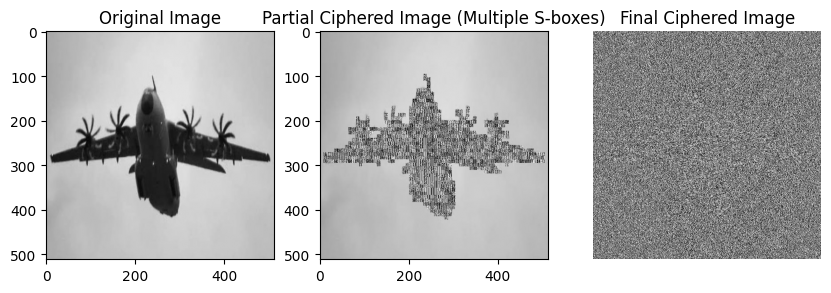

<Figure size 640x480 with 0 Axes>

In [ ]:
# prompt: use multiple s box for generating partial ciphered image

import matplotlib.pyplot as plt
import numpy as np
def sbox_substitution_flat_multiple(Sboxdec, Rseq, Sboxes):
    """
    Applies S-box substitution using multiple S-boxes based on block index.

    Parameters:
    - Sboxdec: The input NumPy array block (e.g., 8x8).
    - Rseq: Permutation sequence (1D array of length row * col).
    - Sboxes: A list or dictionary of S-boxes (NumPy arrays, 16x16).

    Returns:
    - SBim: The resulting NumPy array block after substitution.
    """
    row, col = Sboxdec.shape

    # Flatten the 2D matrix into a 1D array
    flat = Sboxdec.flatten()

    # Apply permutation using Rseq (Rseq should be of length row * col)
    permuted = np.zeros_like(flat)
    # Ensure Rseq indices are within bounds
    valid_indices = np.clip(Rseq, 0, len(flat) - 1)
    for i in range(row * col):
        permuted[i] = flat[valid_indices[i]] # Apply permutation correctly

    # Reshape back to original shape
    Pscramb = permuted.reshape((row, col))

    # Initialize output image
    SBim = np.zeros((row, col), dtype=np.uint8)

    num_sboxes = len(Sboxes)
    if num_sboxes == 0:
        return Pscramb # Return permuted if no S-boxes are provided

    # Perform S-box substitution based on a cycle through the S-boxes
    for i in range(row):
        for j in range(col):
            bin_val = format(Pscramb[i, j], '08b')
            LSBs = bin_val[:4]   # First 4 bits
            MSBs = bin_val[4:]   # Last 4 bits

            LSBsrow = int(LSBs, 2)
            MSBscol = int(MSBs, 2)

            # Determine which S-box to use based on the index of the pixel within the block
            # Use modulo to cycle through available S-boxes
            sbox_index = (i * col + j) % num_sboxes
            current_sbox = Sboxes[sbox_index]

            SBim[i, j] = current_sbox[LSBsrow, MSBscol]

    return SBim


# Generate multiple S-boxes
S1, S2, S3, S4 = generate_random_sboxes(seed=123) # Use a different seed if you want different S-boxes
multiple_sboxes = [S1, S2, S3, S4]

final_blocks = []
# Assuming block_chaotic_seq is a permutation sequence of length 64 (8*8)
if not isinstance(block_chaotic_seq, np.ndarray) or len(block_chaotic_seq) != 64:
    print("Warning: block_chaotic_seq is not valid. Generating a default sequence.")
    block_chaotic_seq = np.random.permutation(64) # Generate a random permutation sequence

for i, block in enumerate(blocks): # Iterate with index to check high_mid_info_index
    # Convert the PIL block to a NumPy array for processing
    try:
        block_np = np.array(block.convert("L")) # Convert to grayscale NumPy array
    except Exception as e:
        print(f"Error converting block {i} to grayscale NumPy array: {e}")
        final_blocks.append(np.zeros((8,8), dtype=np.uint8)) # Append a black block as placeholder
        continue

    if i not in high_mid_info_index:
        final_blocks.append(block_np) # Append the NumPy array
    else:
        # Instead of just rotating, we'll apply the S-box substitution
        # We need to apply the chaotic permutation *before* the S-box
        # and then the S-box substitution.
        # The input to the S-box substitution is the permuted block data.

        # Apply the chaotic permutation (using block_chaotic_seq)
        # This permutation is applied to the *flattened* block data
        block_flat = block_np.flatten()
        permuted_block_flat = np.zeros_like(block_flat)
        # Ensure block_chaotic_seq indices are within bounds
        valid_indices = np.clip(block_chaotic_seq, 0, len(block_flat) - 1)
        for k in range(len(block_flat)):
             permuted_block_flat[k] = block_flat[valid_indices[k]]

        # Reshape the permuted data back to a block shape
        permuted_block = permuted_block_flat.reshape(8, 8)


        # Apply S-box substitution to the permuted block
        # The Rseq parameter in sbox_substitution_flat was previously used for initial
        # permutation before S-box. Now we apply the chaotic permutation explicitly.
        # The Sboxdec parameter is the input to the S-box, which is the permuted block.
        # The R parameter was used to select a single S-box. We need to adapt this
        # to use multiple S-boxes based on pixel position within the block.
        # Let's use the new function sbox_substitution_flat_multiple
        ciphered_block = sbox_substitution_flat_multiple(permuted_block, sequence, multiple_sboxes)


        final_blocks.append(ciphered_block) # Append the ciphered NumPy array


# Combine the final blocks back into an image
if 'im' in globals() and isinstance(im, np.ndarray):
    blocks_per_row = im.shape[1] // 8
    blocks_per_col = im.shape[0] // 8
else:
    print("Warning: Could not determine image shape from 'im'. Using default 64x64 blocks.")
    blocks_per_row = 64
    blocks_per_col = 64

# Ensure final_blocks has the expected number of blocks for combination
expected_blocks = blocks_per_row * blocks_per_col
if len(final_blocks) != expected_blocks:
    print(f"Warning: Number of final blocks ({len(final_blocks)}) does not match expected ({expected_blocks}).")
    # Pad with black blocks if necessary, or handle as an error
    while len(final_blocks) < expected_blocks:
        final_blocks.append(np.zeros((8, 8), dtype=np.uint8))
    # Truncate if too many blocks (shouldn't happen with the current logic if error handling is correct)
    final_blocks = final_blocks[:expected_blocks]


partial_ciphered_image = combine_blocks(final_blocks, blocks_per_row, blocks_per_col)

# Assuming partial_ciphered_image and noisy_image are already defined

# Ensure both arrays are of type np.uint8 for bitwise operations
partial_ciphered_image_uint8 = partial_ciphered_image.astype(np.uint8)
noisy_image_uint8 = noisy_image.astype(np.uint8)

# Perform the bitwise XOR operation
final_ciphered_image = cv2.bitwise_xor(partial_ciphered_image_uint8, noisy_image_uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
plt.imshow(im, cmap='gray')
plt.title("Original Image")
plt.subplot(1,3,2)
plt.imshow(partial_ciphered_image, cmap='gray')
plt.title("Partial Ciphered Image (Multiple S-boxes)")
plt.subplot(1,3,3)
plt.imshow(final_ciphered_image, cmap='gray')
plt.title("Final Ciphered Image")
plt.axis('off')
plt.show()
plt.savefig('image1_plot.png', bbox_inches='tight', pad_inches=0)

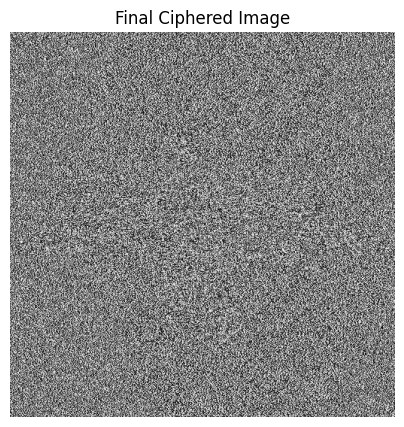

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Ensure cv2 is imported

# Assuming partial_ciphered_image and noisy_image are already defined

# Ensure both arrays are of type np.uint8 for bitwise operations
partial_ciphered_image_uint8 = partial_ciphered_image.astype(np.uint8)
noisy_image_uint8 = noisy_image.astype(np.uint8)

# Perform the bitwise XOR operation
final_ciphered_image = cv2.bitwise_xor(partial_ciphered_image_uint8, noisy_image_uint8)

# Display the final ciphered image
plt.figure(figsize=(5, 5))
plt.imshow(final_ciphered_image, cmap='gray')
plt.title("Final Ciphered Image")
plt.axis('off')
plt.show()